In [57]:
###### import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import numpy as np

In [142]:
phi = var(r'φ') # scalar field
lam = var(r'λ') 
k = 1
lam = 3
show(lam)
V0 = var(r'V_0')

# Expression for V
V = function('V')(phi)
V = V0*exp(-lam*k*phi)
dVdφ  = V.diff(phi)

# V prime:
N = var('N')
Phi = function(r'Φ')(N)
dvdΦ = dVdφ.subs(phi == Phi)
show(dvdΦ)

3

-3*V_0*e^(-3*Φ(N))

In [143]:

ohm_m = 0.31
Ho = 6.1324e-61 # Hubble constant in reduced plank mass units
rho_c0 = (3*Ho^2/(k^2)) # current critical energy density
gam = 4


In [144]:
def solveCopelandKG(X,N):
    a = exp(N) # N = ln(a)
    rho_m = rho_c0*ohm_m*a^(-3)
    Vfunc = V.subs(V0 == rho_c0,phi ==X[0])
    dVfunc = dvdΦ.subs(V0 == rho_c0,Phi ==X[0])
    H2 = (rho_m + Vfunc)/(1-1/6*(X[1])^2)
    #show(H2)
    HdotH2 = -0.5*((X[1])^2+ gam*rho_m/H2)
    x1prime = X[1]
    x2prime = -(3+HdotH2)*X[1] - dVfunc/H2
    return [x1prime,x2prime,Vfunc]

In [145]:
dPhi = Phi.diff(N)
X = [Phi,dPhi]
show(solveCopelandKG([1,0],0))

[0,
 (3.38456967840000e-120)*e^(-3)/((1.12818989280000e-120)*e^(-3) + 3.49738866768000e-121),
 (1.12818989280000e-120)*e^(-3)]

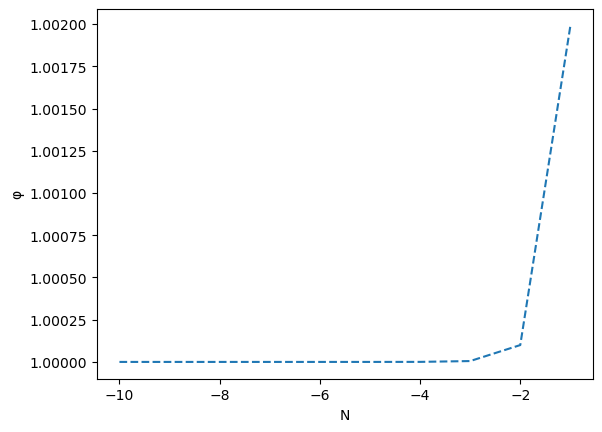

In [146]:
Nrange = np.arange(-10,0,1)
sol = odeint(solveCopelandKG,[1,0,rho_c0],t=Nrange)

# Plot of φ against redshift
phi_sol = sol[:,0]
phi_prime = sol[:,1]
#show(phi_prime)
Vnumber = sol[:,2]
#show(Vnumber)

z_values = exp(-Nrange)
plt.xlabel("N")
plt.ylabel(r"φ")
plt.plot(Nrange,phi_sol,'--')

In [147]:
# Multiple Values of Q
def other_parameters(fi,dfi,V,N):
    a = exp(N) # N = ln(a)
    z = exp(-N)-1
    rho_m = rho_c0*ohm_m*a^(-3)
    H2 = (rho_m + V)/(1-1/6*dfi^2)
    rho_φ = 0.5*(dfi^2*H2) + V #Energy density of φ (ρ_φ)
    #ratio_rho = rho_φ/rho_m
    
    O_φ = ((k^2)/3)*(rho_φ/H2) # Ωφ
    O_m = 1-O_φ
    #ratio_O = O_φ/O_m
    
    Pφ = 0.5*(dfi^2*H2) - V
    Y_φ = (dfi^2*H2)/rho_φ
    w = Pφ/rho_φ #Equation of State wΦ
    return z,rho_φ,Pφ,O_φ,O_m,w,Y_φ

In [148]:
z,rho,P,O_Q,O_m,w,Y_Q = other_parameters(phi_sol,phi_prime,Vnumber,Nrange)
Z = z+1
#show(Y_Q)

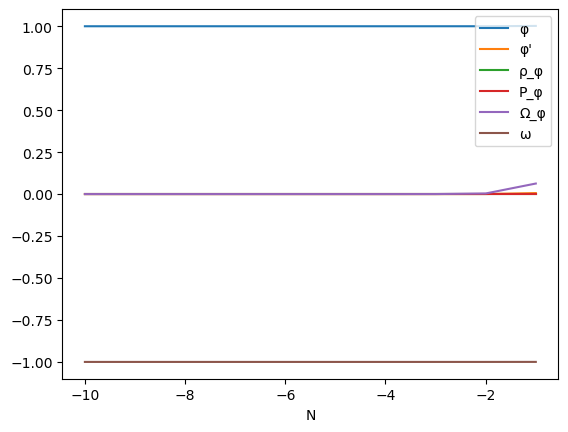

In [149]:
# Plots of φ,φ',ωφ,ρφ,Ωφ vs N

plt.plot(Nrange,phi_sol, label  =r"φ")
plt.plot(Nrange,phi_prime, label  =r"φ'")
plt.plot(Nrange,rho,label=r"ρ_φ")
plt.plot(Nrange,P,label=r"P_φ") 
plt.plot(Nrange,O_Q,label=r"Ω_φ") 
plt.plot(Nrange,w,label=r"ω") 
plt.xlabel("N")
plt.legend()

### Oberservations: change
Parameters experience a change of shape at N = 0. This is current day. \
$P_φ$ is zero for all N. This makes sense as $P_φ = (γ-1)ρ_φ$ and we have set $γ$ to 1. \
$ρ_φ$ is steadily increases from zero at a constant rate for N less than zero before it has a small rapid expansion at N = 0 before it plateaus. \


0.06289708122355966

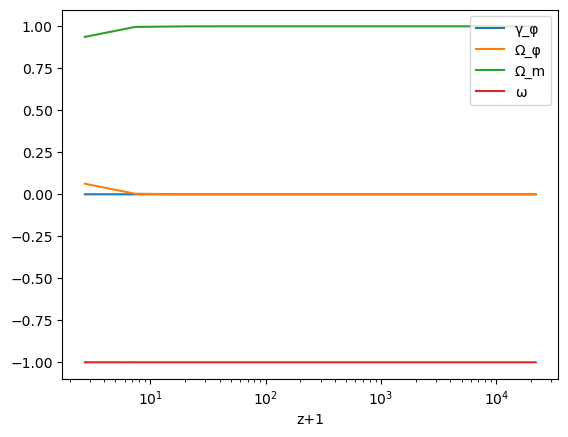

In [150]:
# Plots of φ,φ',ωφ,ρφ,Ωφ vs z+1
#plt.plot(Z,phi_sol, label  =r"φ")
# plt.plot(Z,phi_prime, label  =r"φ'")
#plt.plot(Z,rho,label=r"ρ_φ")
#show(Y_Q)
plt.plot(Z,Y_Q,label=r"γ_φ")
#plt.plot(Z,ratio_O,label = r"ratio_Ω")
#plt.plot(Z,P,label=r"P_φ")
show(max(O_Q))
plt.plot(Z,O_Q,label=r"Ω_φ") 
plt.plot(Z,O_m,label=r"Ω_m")
#plt.plot(Z,O_m/O_Q,label=r"ratio_Ω")
plt.plot(Z,w,label=r"ω") 
plt.xlabel("z+1")
plt.xscale('log')
plt.legend()

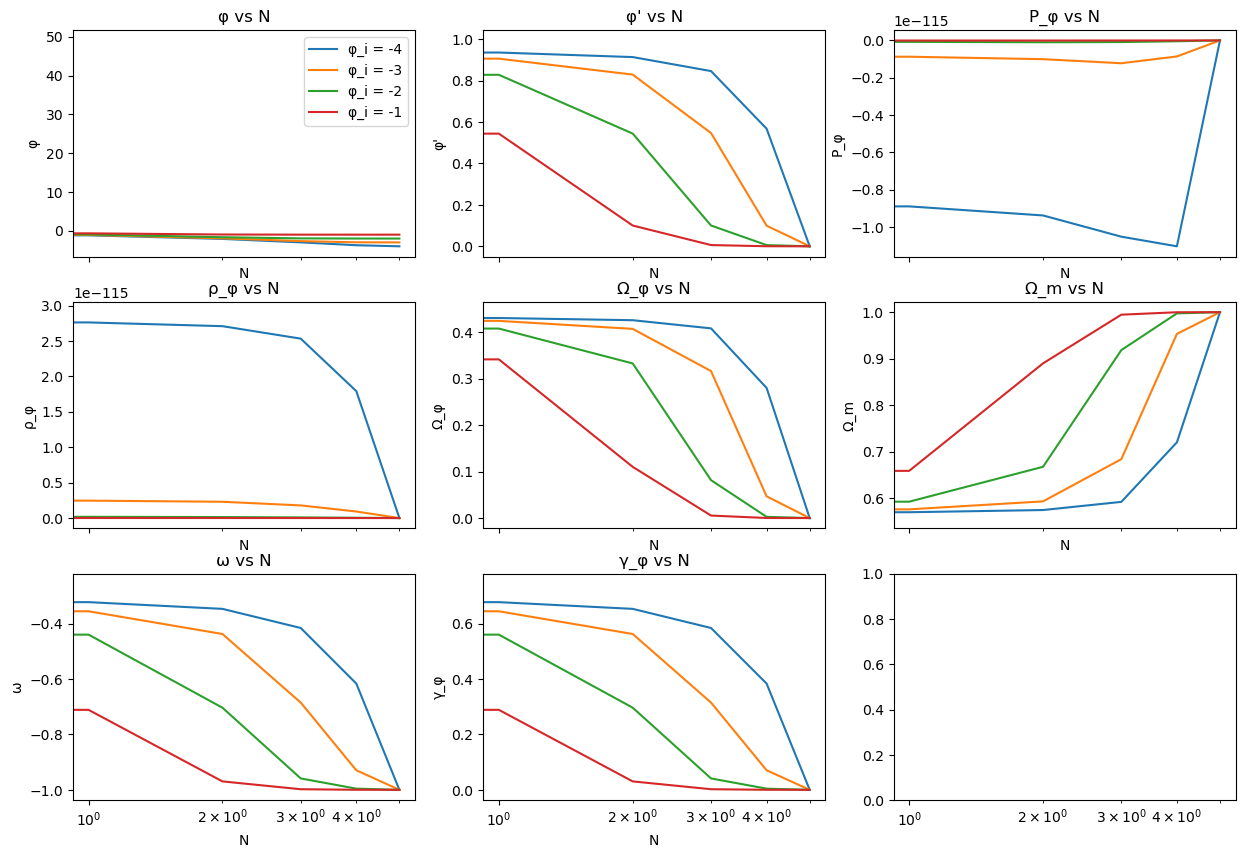

In [152]:
# Test for Attacting Q values
Nrange = np.arange(-5,51,1)
z_list = []
rho_list = []
P_list = []
om_list = []
w_list = []
Q_list = []
fig, axs = plt.subplots(3,3, figsize=(15, 10),sharex=True)

for i in range(-4,0,1):
    solQ = odeint(solveCopelandKG,[i,0,rho_c0],t=Nrange)
    '''When I generate solutions, I also find the corresponding z,ωφ,ρφ,Ωφ,Pφ values for all initial Q values ranged. '''
    z,rho,P,O_Q,O_m,w,Y_Q = other_parameters(solQ[:,0],solQ[:,1],solQ[:,2],Nrange)
    z_list.append(z);rho_list.append(rho);P_list.append(P);om_list.append(om);w_list.append(w)

    # Use Subplots to observe each parameter over all N for a different intial value of φ
    axs[0,0].plot(-Nrange,solQ[:,0],label=r"φ_i = {}".format(i))
    axs[0,0].set(ylabel = r"φ", xlabel = "N",title=r"φ vs N")
    axs[0,0].legend()

    axs[0,1].plot(-Nrange,solQ[:,1],label=r"φ_i = {}".format(i))
    axs[0,1].set(ylabel = r"φ'", xlabel = "N",title=r"φ' vs N")
    #axs[0,1].legend()

    axs[0,2].plot(-Nrange,P,label=r"φ_i = {}".format(i))
    axs[0,2].set(ylabel = r"P_φ", xlabel = "N",title=r"P_φ vs N")
    #axs[0,2].legend()

    axs[1,0].plot(-Nrange,rho,label=r"φ_i = {}".format(i))
    axs[1,0].set(ylabel = r"ρ_φ", xlabel = "N",title=r"ρ_φ vs N")
    #axs[1,0].legend()

    axs[1,1].plot(-Nrange,O_Q,label=r"φ_i = {}".format(i))
    axs[1,1].set(ylabel = r"Ω_φ", xlabel = "N",title=r"Ω_φ vs N")
    #axs[1,1].legend()

    axs[1,2].plot(-Nrange,O_m,label=r"φ_i = {}".format(i))
    axs[1,2].set(ylabel = r"Ω_m", xlabel = "N",title=r"Ω_m vs N")
    #axs[1,2].legend()

    axs[2,0].plot(-Nrange,w,label=r"φ_i = {}".format(i))
    axs[2,0].set(ylabel = r"ω", xlabel = "N",title=r"ω vs N")
    #axs[2,0].legend()

    axs[2,1].plot(-Nrange,Y_Q,label=r"φ_i = {}".format(i))
    axs[2,1].set(ylabel = r"γ_φ", xlabel = "N",title=r"γ_φ vs N")
    #axs[2,1].legend()
    

axs[0,0].set_xscale('log')
#axs[0,0].set_yscale('log')

#def multipleQ(Q,N):
#axs[0,0].ylabel()
    #axs[0,0].xlabel()    
    

### Improvement to code above:
The code below is the same as the code above, but now allows you to easily choose what is plotted on the x-axis. Also changed the range of N values to include Negative values as well. 

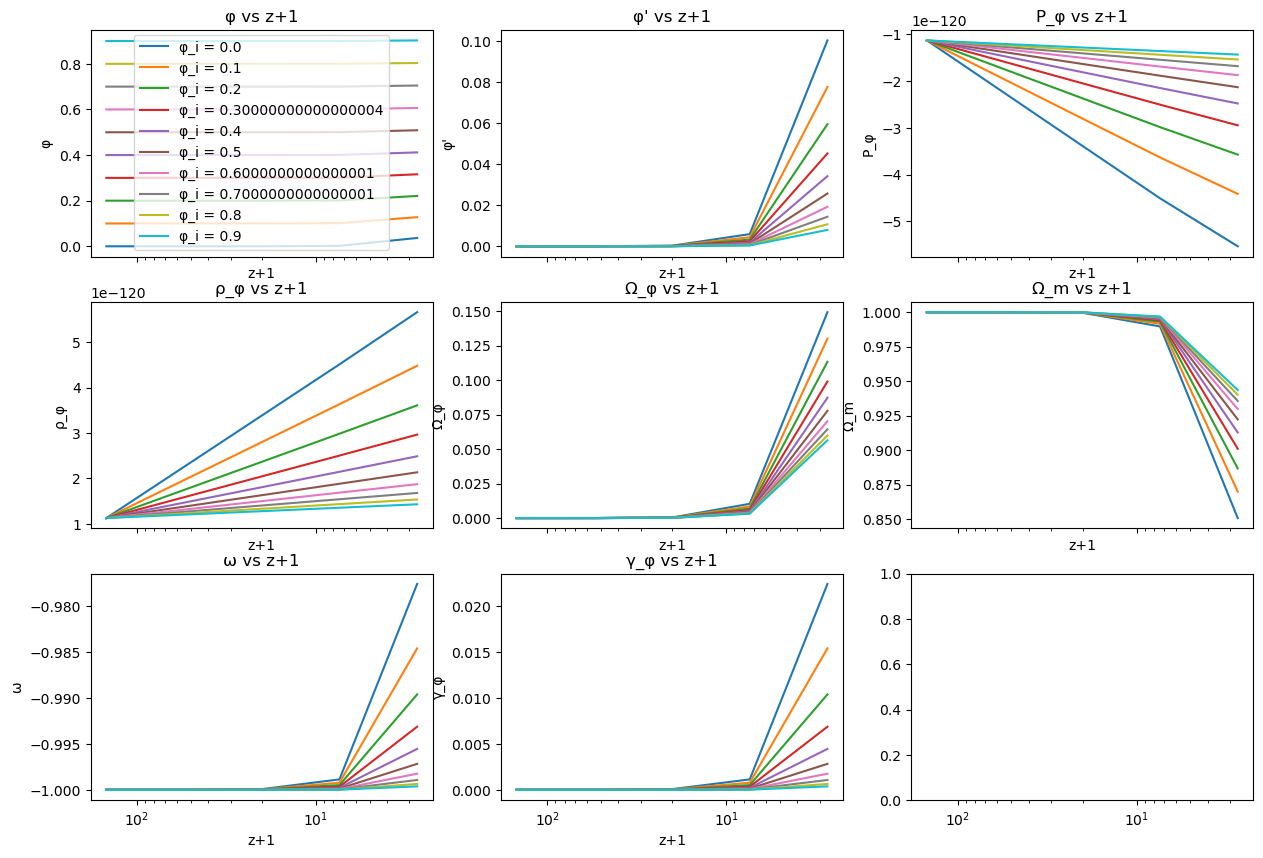

In [153]:
Nrange = np.arange(-5,0,1)
fig, axs = plt.subplots(3,3, figsize=(15, 10),sharex=True)
def xaxis(x,label,i):
    axs[0,0].set_xscale('log')
        
    #axs[0,0].set_yscale('log')
    axs[0,0].plot(x,solQ[:,0],label=r"φ_i = {}".format(i))
    axs[0,0].set(ylabel = r"φ", xlabel = "{}".format(label),title=r"φ vs {}".format(label))
    if label == "z+1":
        axs[0,0].xaxis.set_inverted(True)
    axs[0,0].legend()
    
    axs[0,1].plot(x,solQ[:,1],label=r"φ_i = {}".format(i))
    axs[0,1].set(ylabel = r"φ'", xlabel = "{}".format(label),title=r"φ' vs {}".format(label))
    #axs[0,1].legend()
    
    axs[0,2].plot(x,P,label=r"φ_i = {}".format(i))
    axs[0,2].set(ylabel = r"P_φ", xlabel = "{}".format(label),title=r"P_φ vs {}".format(label))
    #axs[0,2].legend()
    
    axs[1,0].plot(x,rho,label=r"φ_i = {}".format(i))
    axs[1,0].set(ylabel = r"ρ_φ", xlabel = "{}".format(label),title=r"ρ_φ vs {}".format(label))
    #axs[1,0].legend()
    
    axs[1,1].plot(x,O_Q,label=r"φ_i = {}".format(i))
    axs[1,1].set(ylabel = r"Ω_φ", xlabel = "{}".format(label),title=r"Ω_φ vs {}".format(label))
    #axs[1,1].legend()
    
    axs[1,2].plot(x,O_m,label=r"φ_i = {}".format(i))
    axs[1,2].set(ylabel = r"Ω_m", xlabel = "{}".format(label),title=r"Ω_m vs {}".format(label))
    #axs[1,2].legend()

    axs[2,0].plot(x,w,label=r"φ_i = {}".format(i))
    axs[2,0].set(ylabel = r"ω", xlabel = "{}".format(label),title=r"ω vs {}".format(label))
    #axs[2,0].legend()

    axs[2,1].plot(x,Y_Q,label=r"φ_i = {}".format(i))
    axs[2,1].set(ylabel = r"γ_φ", xlabel = "{}".format(label),title=r"γ_φ vs {}".format(label))
    #axs[2,1].legend()
    
Q_values = np.arange(0,1,0.1)
for i in Q_values:
    solQ = odeint(solveCopelandKG,[i,0,rho_c0],t=Nrange)
    '''When I generate solutions, I also find the corresponding z,ωφ,ρφ,Ωφ,Pφ values for all initial Q values ranged. '''
    z,rho,P,O_Q,O_m,w,Y_Q = other_parameters(solQ[:,0],solQ[:,1],solQ[:,2],Nrange)
    Z = z+1
    xaxis(Z,"z+1",i) # Here is where you can alter whether to view graphs w.r.t to N or z+1
